In [1]:
import pandas as pd
import numpy as np
import matplotlib.ticker as mtick
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x : '%.4f' % x)
import sys
sys.path.append('..')
from SRC import sp_limpieza_bank as slb 
from SRC import sp_visualizacion as sv
from SRC import sp_eda as se
from SRC import sp_nulos_num as snn
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('../Data/data_limpios_customer.csv')
df.head()

,Income,Kid_Home,Teen_Home,Dt_Customer,Num_Web_Visits_Month,ID,Join_Year
0,161770,1,0,2012-04-04,29,089b39d8-e4d0-461b-87d4-814d71e0e079,2012
1,85477,1,1,2012-12-30,7,e9d37224-cb6f-4942-98d7-46672963d097,2012
2,147233,1,1,2012-02-02,5,3f9f49b5-e410-4948-bf6e-f9244f04918b,2012
3,121393,1,2,2012-12-21,29,9991fafb-4447-451a-8be2-b0df6098d13e,2012
4,63164,1,2,2012-06-20,20,eca60b76-70b6-4077-80ba-bc52e8ebb0eb,2012


## Gestion de las columnas numericas de customer

In [3]:
columnas_num = df.select_dtypes(include=np.number).columns.tolist()
print(columnas_num)

['Income', 'Kid_Home', 'Teen_Home', 'Num_Web_Visits_Month', 'Join_Year']


In [4]:
df[columnas_num].describe().T

,count,mean,std,min,25%,50%,75%,max
Income,43170.0000,93227.3896,50498.1820,5841.0000,49608.0000,93009.5000,136740.5000,180802.0000
Kid_Home,43170.0000,1.0047,0.8160,0.0000,0.0000,1.0000,2.0000,2.0000
Teen_Home,43170.0000,0.9986,0.8160,0.0000,0.0000,1.0000,2.0000,2.0000
Num_Web_Visits_Month,43170.0000,16.5913,9.2418,1.0000,9.0000,17.0000,25.0000,32.0000
Join_Year,43170.0000,2012.8604,0.8791,2012.0000,2012.0000,2013.0000,2014.0000,2014.0000


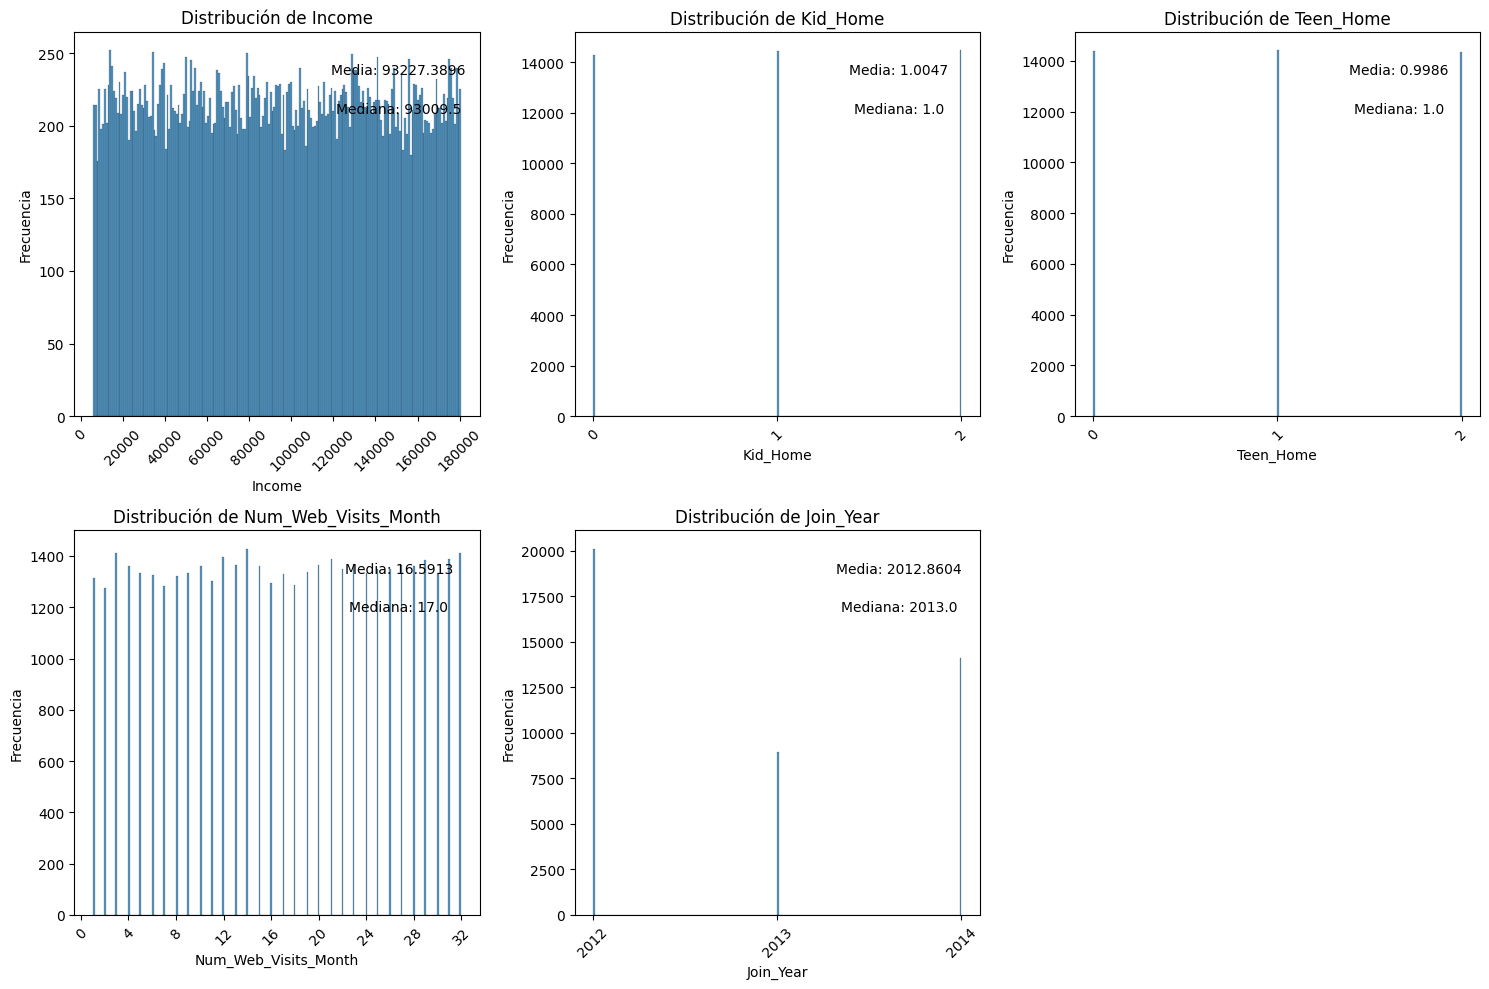

In [5]:
num_graph = len(columnas_num)

num_rows = (num_graph +2 )//3

fig, axes = plt.subplots(num_rows, 3, figsize=(15, num_rows*5))
axes = axes.flatten()

for i, col in enumerate(columnas_num):
    sns.histplot(data=df, x=col, ax = axes[i], bins=200)
    axes[i].text(0.8, 0.9, f'Media: {round(df[col].mean(),4)}', horizontalalignment='center', verticalalignment='center', transform=axes[i].transAxes)
    axes[i].text(0.8, 0.8, f'Mediana: {df[col].median()}', horizontalalignment='center', verticalalignment='center', transform=axes[i].transAxes)
    axes[i].set_title(f'Distribución de {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frecuencia')
    axes[i].tick_params(axis='x', rotation=45)
    axes[i].xaxis.set_major_locator(mtick.MaxNLocator(integer=True))
    
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [6]:
col_high_umbral, col_low_umbral = snn.calcular_solo_col_nuls(df.select_dtypes(include=np.number))

,Column,Datatype,NullCount,Null%


In [7]:
se.calcular_porcentaje_nulos(df)

(Income                  0
 Kid_Home                0
 Teen_Home               0
 Dt_Customer             0
 Num_Web_Visits_Month    0
 ID                      0
 Join_Year               0
 dtype: int64,
 Income                 0.0000
 Kid_Home               0.0000
 Teen_Home              0.0000
 Dt_Customer            0.0000
 Num_Web_Visits_Month   0.0000
 ID                     0.0000
 Join_Year              0.0000
 dtype: float64)

In [8]:
df.to_csv('../Data/data_limpios_customer.csv', index = False)